In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import Food101
from torchvision.transforms import ToTensor

import pandas as pd 
import matplotlib.pyplot as plt 

print(f"Torch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

Torch Version: 2.10.0+cu130
Torchvision Version: 0.25.0+cu130


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


# Import/Explore Datasets

In [5]:
train_data = Food101(
    root="data", 
    split="train",
    transform=ToTensor(),
    target_transform= None,
    download=True
)

test_data = Food101(
    root="data",
    split="test",
    transform=ToTensor(),
    target_transform= None,
    download=True
)

In [6]:
print(f"Length of Test dataset: {len(train_data)}")
print(f"Length of Test dataset: {len(test_data)}")

Length of Test dataset: 75750
Length of Test dataset: 25250


In [7]:
class_names, labels = train_data.classes, train_data._labels


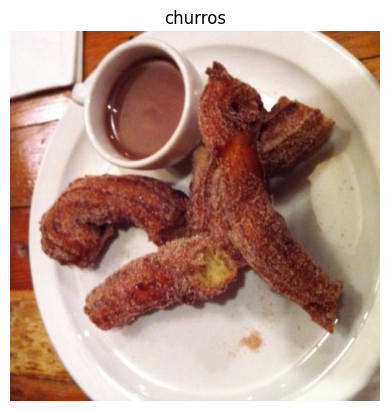

In [8]:
image, label = train_data[0]
plt.title(class_names[label])
plt.imshow(image.permute(2, 1, 0))
plt.axis(False)
plt.show()

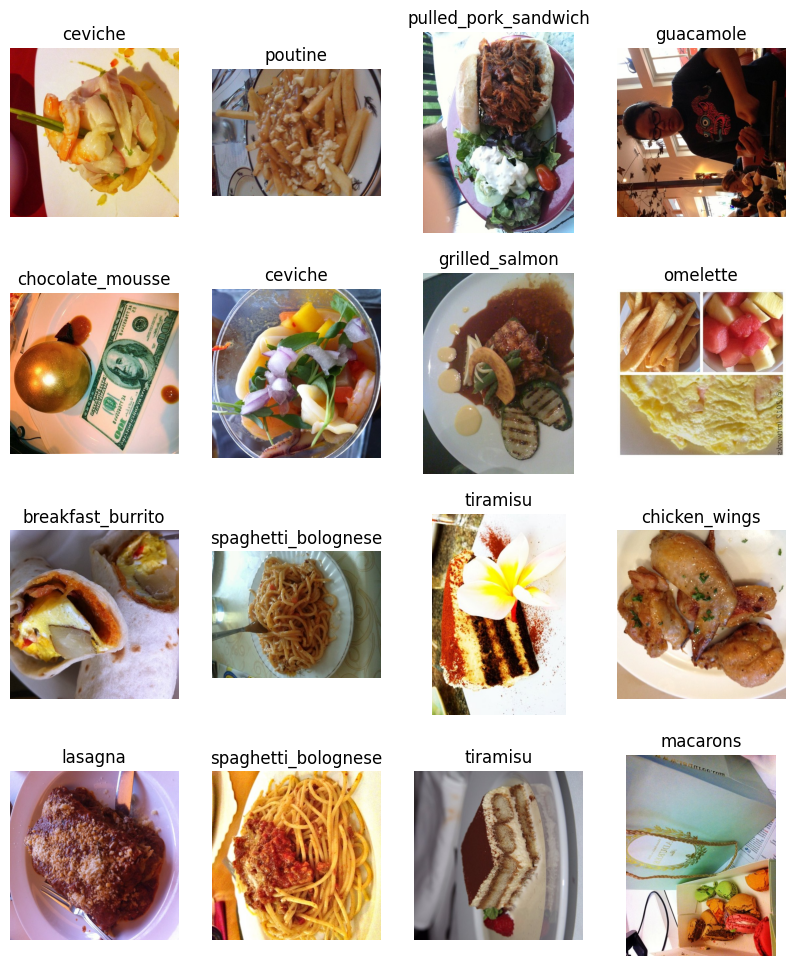

In [9]:
# Visualize More Data
nrows, ncols = 4, 4 
fig = plt.figure(figsize=(10, 12))
for i in range(1, nrows * ncols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(nrows, ncols, i)
    plt.title(class_names[label])
    plt.imshow(image.permute(2, 1, 0))
    plt.axis(False)

# DataLoaders

In [10]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Original Training Data: {len(train_data)}")
print(f"Original Testing Data: {len(test_data)}")
print(f"{len(train_dataloader)} train data on batches of {BATCH_SIZE}")
print(f"{len(test_dataloader)} train data on batches of {BATCH_SIZE}")

Original Training Data: 75750
Original Testing Data: 25250
2368 train data on batches of 32
790 train data on batches of 32


# Create Models

In [11]:
class Food101V0(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()
        self.stack_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_units,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_units)
        )
    
    def forward(self, x: torch.Tensor):
        return self.stack_layer(x)

In [12]:
class Food101V1(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()
        self.stack_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=output_units),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.stack_layer(x)

In [28]:
class Food101V2(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()

        # Resize layer — shrinks any image down to 64x64 automatically
        self.resize = nn.AdaptiveAvgPool2d((64, 64))

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU()
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU()
        )

        self.poolingLayer = nn.MaxPool2d(kernel_size=3, stride=1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 60 * 60,  # Update after checking shape
                      out_features=output_units)
        )

    def forward(self, x: torch.Tensor):
        x = self.resize(x)        # Resize first
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.poolingLayer(x)
        x = self.conv_block2(x)
        x = self.conv_block2(x)
        x = self.poolingLayer(x)
        print(x.shape)            # Check shape then remove
        x = self.classifier(x)
        return x

# Instantiate Models

In [14]:
model_0 = Food101V0(input_units=len(train_data),
                    hidden_units=512,
                    output_units=len(class_names)).to(device=device)

model_0

Food101V0(
  (stack_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=75750, out_features=512, bias=True)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=101, bias=True)
  )
)

In [15]:
model_1 = Food101V1(input_units=len(train_data),
                    hidden_units=512,
                    output_units=len(class_names)).to(device=device)

model_1

Food101V1(
  (stack_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=75750, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=101, bias=True)
    (6): ReLU()
  )
)

In [29]:
model_2 = Food101V2(input_units=len(train_data),
                    hidden_units=512,
                    output_units=len(class_names)).to(device=device)

model_2

Food101V2(
  (resize): AdaptiveAvgPool2d(output_size=(64, 64))
  (conv_block1): Sequential(
    (0): Conv2d(75750, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (conv_block2): Sequential(
    (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (poolingLayer): MaxPool2d(kernel_size=3, stride=1, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1843200, out_features=101, bias=True)
  )
)

# Create Training and Testing Functions

In [ ]:
# CroossEntropyLoss -> Multiclass classification
loss_fn = nn.CrossEntropyLoss()

# SGD -> Stochastic gradient descent 
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr = 0.01,
                            momentum=0.9)

In [ ]:
def accuracy_fn(y_true, y_pred):
    """
    Checks the accuracy of a model 

    Args:
        y_true (torch.Tensor): True labels for the data
        y_preds (torch.Tensor): Predicted labels for the data 

    Returns:
        [torch.float]: Accuracy of a between y_true and y_preds
    """

    correct_preds = torch.eq(y_true, y_pred).sum().item()

    acc =  (correct_preds/len(y_pred)) * 100
    return acc

In [ ]:
# Train Function
def train_step(model: nn.Module, 
               dataloader: DataLoader, 
               loss_fn: nn.Module,
               accuracy_fn, 
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):
    """
    Functioninzing the training process for an ai model 

    Args:
        model (torch.nn.Module): Takes the model as an argument for training
        dataloader (torch.utils.data.DataLoader): Takes dataloader for training 
        loss_fn (torch.nn.Module): Takes the loss function for the model as a parameter for loss calculation
        accuracy_fn (torch.optim.Optimizer): Takes the optimizer as an argument for nudging the models paramters 
        device (torch.device): Takes the current device at use for calculations

    Output:
        Training Loss | Training Accuracy
    """
    train_loss, train_acc = 0, 0
    model.to(device=device)
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Forward Pass
        y_pred = model(X)

        # Calculate loss
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred)
        train_loss += loss
        train_acc += acc

        # Zero Step
        optimizer.zero_grad()

        # Loss Backward
        loss.backward()

        # Optim Step
        optimizer.step()
    
    # Calculate Loss/Accuracy Per Epoch
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    # Print whats happening 
    print(f"Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}")

In [30]:
# Test Fucntion
def test_function(model: nn.Module, 
                  dataloader: DataLoader, 
                  loss_fn: nn.Module, 
                  accuracy_fn, 
                  device: torch.device = device):
    """
    Functioninzing the testing process for an ai model 

    Args:
        model (torch.nn.Module): Takes the model as an argument for testing
        dataloader (torch.utils.data.DataLoader): Takes dataloader for testing 
        loss_fn (torch.nn.Module): Takes the loss function for the model as a parameter for loss calculation
        accuracy_fn (torch.optim.Optimizer): Takes the optimizer as an argument for nudging the models paramters 
        device (torch.device): Takes the current device at use for calculations

    Output:
        Testing Loss | Testing Accuracy
    """
    model.to(device=device)

    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for batches, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # Forward Pass
            y_pred = model(X)

            # Calculate Loss/Accuracy
            loss = loss_fn(y_pred, y)
            test_loss += loss
            accuracy = accuracy_fn(y_true=y, y_pred= y_pred)
            test_acc += accuracy

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

        # Print whats happening 
        print(f"Test Loss: {test_loss} | Test Accuracy: {test_acc}")

# Train Models